In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles_clean.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


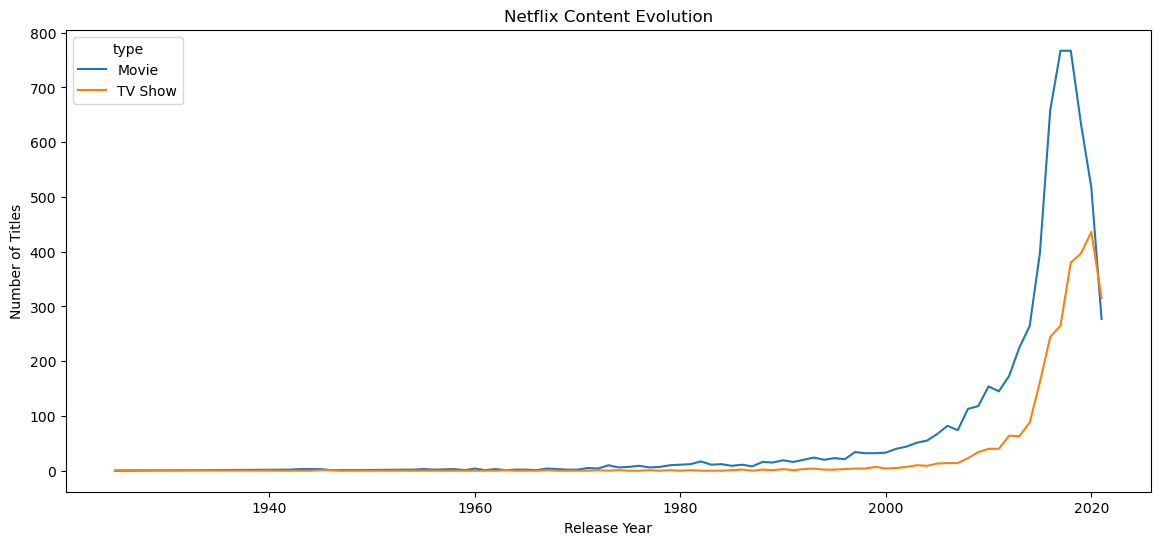

In [2]:
#11. How has Netflix's content library evolved over time?

content_trend = (
    df.groupby(['release_year', 'type'])
      .size()
      .unstack(fill_value=0)
)

content_trend.plot(figsize=(14,6))

plt.title("Netflix Content Evolution")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [3]:
#12. Which genres have grown the fastest over the last decade?

genre_growth = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
      .groupby(['release_year','listed_in'])
      .size()
      .unstack(fill_value=0)
)

last_10_years = genre_growth.loc[genre_growth.index >= (df['release_year'].max()-10)]

growth = last_10_years.iloc[-1] - last_10_years.iloc[0]

print(growth.sort_values(ascending=False).head(10))

listed_in
International TV Shows    126
International Movies       86
TV Dramas                  74
TV Comedies                62
Docuseries                 50
Documentaries              46
Crime TV Shows             43
Reality TV                 42
Kids' TV                   34
Dramas                     32
dtype: int64


In [4]:
#13. Which countries focus more on Movies than TV Shows?

country_type = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
      .groupby(['country','type'])
      .size()
      .unstack(fill_value=0)
)

country_type['Movie Ratio'] = (
    country_type['Movie'] /
    (country_type['Movie'] + country_type['TV Show'])
)

print(country_type.sort_values('Movie Ratio', ascending=False).head(15))

type           Movie  TV Show  Movie Ratio
country                                   
Lithuania          1        0          1.0
Paraguay           1        0          1.0
Palestine          1        0          1.0
Nicaragua          1        0          1.0
Nepal              2        0          1.0
Namibia            2        0          1.0
Mozambique         1        0          1.0
Morocco            6        0          1.0
Montenegro         1        0          1.0
Mongolia           1        0          1.0
Malawi             1        0          1.0
Afghanistan        1        0          1.0
Liechtenstein      1        0          1.0
Latvia             1        0          1.0
Kenya              6        0          1.0


In [5]:
#14. Which directors specialize in TV Shows?

tv_directors = (
    df[df['type']=='TV Show']
      .assign(director=df['director'].str.split(', '))
      .explode('director')
)

print(tv_directors['director'].value_counts().head(15))

Alastair Fothergill      3
Ken Burns                3
Jung-ah Im               2
Gautham Vasudev Menon    2
Iginio Straffi           2
Hsu Fu-chun              2
Stan Lathan              2
Joe Berlinger            2
Shin Won-ho              2
Lynn Novick              2
Rob Seidenglanz          2
Chen Hung-yi             1
Weica Wang               1
Jerry Seinfeld           1
Lin Guan-fu              1
Name: director, dtype: int64


In [7]:
#15. Which countries produce the longest movies?

movies = df[df['type'] == 'Movie'].copy()

# Keep only rows where both duration and country are available
movies = movies.dropna(subset=['duration', 'country'])

# Remove " min" from duration
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)

# Convert to numeric (invalid values become NaN)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Remove any remaining invalid durations
movies = movies.dropna(subset=['duration'])

# Split multiple countries into separate rows
movies = movies.assign(country=movies['country'].str.split(', '))
movies = movies.explode('country')

# Remove extra spaces from country names
movies['country'] = movies['country'].str.strip()

# Calculate average duration by country
avg_duration = (
    movies.groupby('country')['duration']
    .mean()
    .sort_values(ascending=False)
)

print(avg_duration.head(15))

country
Liechtenstein    200.000000
Montenegro       157.000000
Soviet Union     156.666667
Bahamas          145.000000
Cameroon         143.000000
Morocco          137.333333
Malta            135.500000
India            125.912682
Ethiopia         125.000000
Burkina Faso     125.000000
Pakistan         122.300000
Romania          121.571429
Sudan            118.000000
Somalia          118.000000
Malawi           114.000000
Name: duration, dtype: float64


In [8]:
#16. Which ratings dominate each genre?

genre_rating = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
      .groupby(['listed_in','rating'])
      .size()
)

dominant = genre_rating.groupby(level=0).idxmax()

print(dominant)

listed_in
Action & Adventure                            (Action & Adventure, R)
Anime Features                                (Anime Features, TV-14)
Anime Series                                    (Anime Series, TV-14)
British TV Shows                            (British TV Shows, TV-MA)
Children & Family Movies               (Children & Family Movies, PG)
Classic & Cult TV                          (Classic & Cult TV, TV-14)
Classic Movies                                    (Classic Movies, R)
Comedies                                            (Comedies, TV-14)
Crime TV Shows                                (Crime TV Shows, TV-MA)
Cult Movies                                          (Cult Movies, R)
Documentaries                                  (Documentaries, TV-MA)
Docuseries                                        (Docuseries, TV-MA)
Dramas                                                (Dramas, TV-MA)
Faith & Spirituality                    (Faith & Spirituality, TV-PG)
Horror Mov

In [9]:
#17. What percentage of Netflix content is produced in the United States?
    
usa_titles = df['country'].fillna('').str.contains('United States').sum()

percentage = usa_titles / len(df) * 100

print(f"USA Content: {percentage:.2f}%")

USA Content: 41.90%


In [10]:
#18. Which countries have the most diverse genres?

country_genres = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
      .assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

diversity = (
    country_genres.groupby('country')['listed_in']
    .nunique()
    .sort_values(ascending=False)
)

print(diversity.head(15))

country
United States     42
Canada            37
United Kingdom    37
Australia         36
India             35
France            35
Japan             35
Spain             32
Germany           32
Mexico            31
China             31
Argentina         30
South Korea       29
Italy             28
Brazil            27
Name: listed_in, dtype: int64


In [11]:
#19. Which genres are most common for TV Shows?

tv_genres = (
    df[df['type']=='TV Show']
      .assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

print(tv_genres['listed_in'].value_counts().head(10))

International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: listed_in, dtype: int64


In [12]:
#20. Which genres are most common for Movies?

movie_genres = (
    df[df['type']=='Movie']
      .assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

print(movie_genres['listed_in'].value_counts().head(10))

International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: listed_in, dtype: int64
